In [1]:
import os, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Chemins MRL Eye Dataset
MRL_TRAIN = '/kaggle/input/datasets/akashshingha850/mrl-eye-dataset/data/train'
MRL_VAL   = '/kaggle/input/datasets/akashshingha850/mrl-eye-dataset/data/val'
MRL_TEST  = '/kaggle/input/datasets/akashshingha850/mrl-eye-dataset/data/test'

print("✅ MRL Train:")
for cls in os.listdir(MRL_TRAIN):
    print(f"   {cls}: {len(os.listdir(os.path.join(MRL_TRAIN, cls)))} images")

print("\n✅ MRL Val:")
for cls in os.listdir(MRL_VAL):
    print(f"   {cls}: {len(os.listdir(os.path.join(MRL_VAL, cls)))} images")

2026-06-01 12:44:49.585279: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780317889.997677      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780317890.120409      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780317891.142237      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780317891.142287      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780317891.142290      22 computation_placer.cc:177] computation placer alr

✅ MRL Train:
   sleepy: 25167 images
   awake: 25770 images

✅ MRL Val:
   sleepy: 8389 images
   awake: 8591 images


In [2]:
IMG_SIZE   = (64, 64)
BATCH_SIZE = 128

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    MRL_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    MRL_VAL,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_datagen.flow_from_directory(
    MRL_TEST,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"✅ Classes : {train_gen.class_indices}")
print(f"📊 Train : {train_gen.samples} | Val : {val_gen.samples} | Test : {test_gen.samples}")

Found 50937 images belonging to 2 classes.
Found 16980 images belonging to 2 classes.
Found 16981 images belonging to 2 classes.
✅ Classes : {'awake': 0, 'sleepy': 1}
📊 Train : 50937 | Val : 16980 | Test : 16981


In [3]:
base_model = MobileNetV2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights='imagenet'
)

# Fine-tuning : dégeler les 40 dernières couches
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

eye_model = Model(inputs=base_model.input, outputs=output)

eye_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

print(f"✅ Paramètres entraînables : {sum([p.numpy().size for p in eye_model.trainable_weights]):,}")

/tmp/ipykernel_22/2548970893.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(
I0000 00:00:1780317990.478636      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780317990.485472      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Paramètres entraînables : 2,045,057


In [4]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('/kaggle/working/eye_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("🚀 Entraînement CNN Yeux...")
print("=" * 50)

history = eye_model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Terminé !")
print(f"🏆 Meilleure val_accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"🏆 Meilleure val_AUC      : {max(history.history['val_AUC']):.4f}")

🚀 Entraînement CNN Yeux...
Epoch 1/20


I0000 00:00:1780318008.636788      88 service.cc:152] XLA service 0x78424c015400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780318008.636828      88 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780318008.636832      88 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780318010.946841      88 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-01 12:47:01.535651: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 12:47:01.678894: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 12:47:01.818090: E external/local_xl

 54/398 ━━━━━━━━━━━━━━━━━━━━ 8:15 1s/step - AUC: 0.7094 - accuracy: 0.6520 - loss: 0.6498

2026-06-01 12:48:38.450411: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 12:48:38.595364: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 12:48:38.734286: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - AUC: 0.9046 - accuracy: 0.8299 - loss: 0.3572

2026-06-01 12:59:33.299888: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 12:59:33.436606: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.82674, saving model to /kaggle/working/eye_model.keras

Epoch 1: finished saving model to /kaggle/working/eye_model.keras
398/398 ━━━━━━━━━━━━━━━━━━━━ 780s 2s/step - AUC: 0.9682 - accuracy: 0.9032 - loss: 0.2269 - val_AUC: 0.9281 - val_accuracy: 0.8267 - val_loss: 0.4298 - learning_rate: 1.0000e-04
Epoch 2/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - AUC: 0.9924 - accuracy: 0.9599 - loss: 0.1062
Epoch 2: val_accuracy improved from 0.82674 to 0.91413, saving model to /kaggle/working/eye_model.keras

Epoch 2: finished saving model to /kaggle/working/eye_model.keras
398/398 ━━━━━━━━━━━━━━━━━━━━ 310s 779ms/step - AUC: 0.9931 - accuracy: 0.9626 - loss: 0.1008 - val_AUC: 0.9780 - val_accuracy: 0.9141 - val_loss: 0.2361 - learning_rate: 1.0000e-04
Epoch 3/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - AUC: 0.9952 - accuracy: 0.9710 - loss: 0.0827
Epoch 3: val_accuracy improved from 0.91413 to 0.92733, saving model to /kaggle/working/eye_model

📊 Évaluation sur Test Set...


2026-06-01 14:38:09.028571: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 14:38:09.165874: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


✅ Test Accuracy : 0.9891
✅ Test AUC      : 0.9986

📋 Classification Report:
              precision    recall  f1-score   support

       Awake       0.98      0.99      0.99      8591
      Sleepy       0.99      0.98      0.99      8390

    accuracy                           0.99     16981
   macro avg       0.99      0.99      0.99     16981
weighted avg       0.99      0.99      0.99     16981



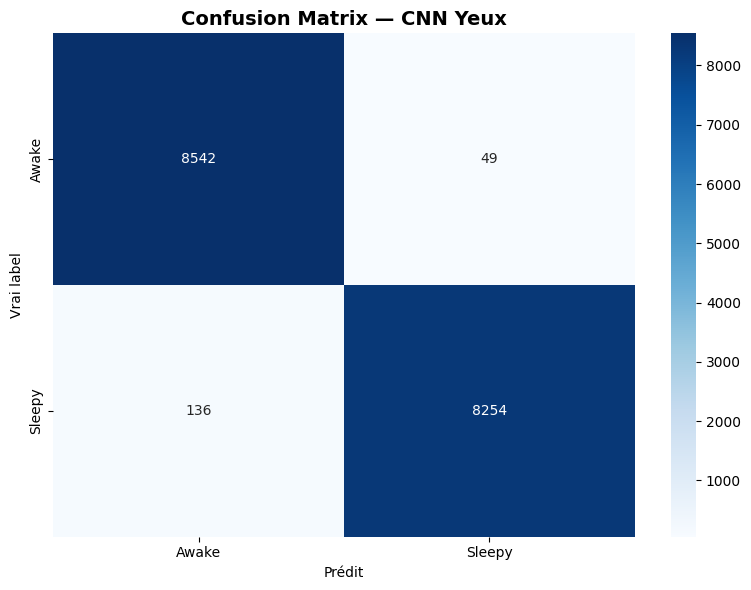

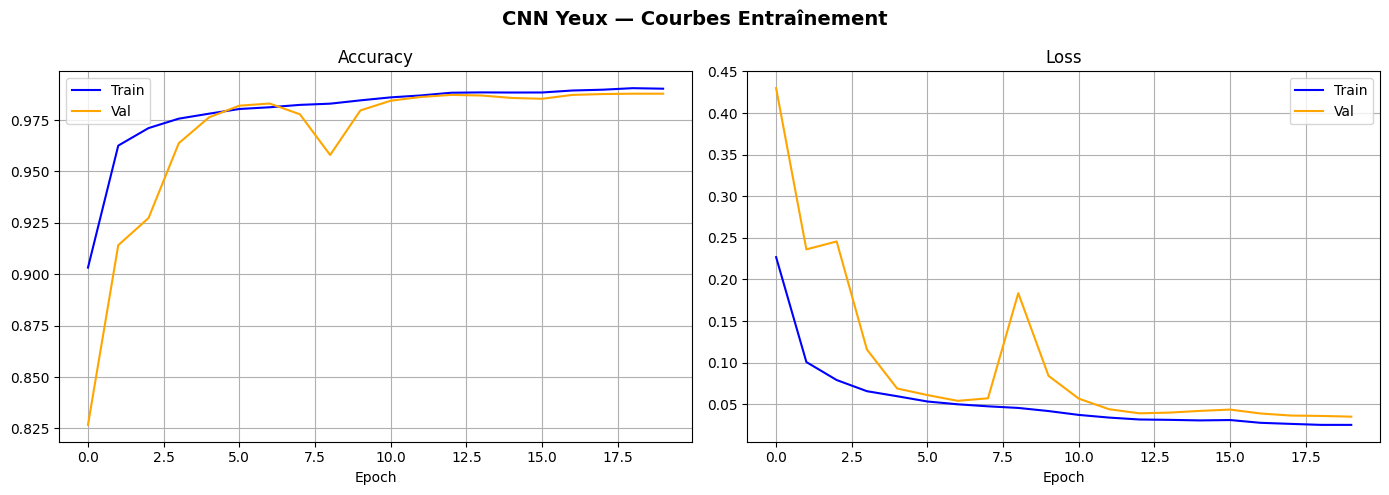

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Évaluation sur test set
print("📊 Évaluation sur Test Set...")
test_loss, test_acc, test_auc = eye_model.evaluate(test_gen, verbose=0)
print(f"✅ Test Accuracy : {test_acc:.4f}")
print(f"✅ Test AUC      : {test_auc:.4f}")

# Prédictions
y_pred_prob = eye_model.predict(test_gen, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.classes

# Rapport
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred,
      target_names=['Awake', 'Sleepy']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Awake', 'Sleepy'],
            yticklabels=['Awake', 'Sleepy'])
plt.title('Confusion Matrix — CNN Yeux', fontsize=14, fontweight='bold')
plt.ylabel('Vrai label')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

# Courbes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val', color='orange')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train', color='blue')
ax2.plot(history.history['val_loss'], label='Val', color='orange')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

plt.suptitle('CNN Yeux — Courbes Entraînement', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
YAWN_TRAIN = '/kaggle/input/datasets/serenaraju/yawn-eye-dataset-new/dataset_new/train'
YAWN_TEST  = '/kaggle/input/datasets/serenaraju/yawn-eye-dataset-new/dataset_new/test'

# Generators
yawn_train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
).flow_from_directory(
    YAWN_TRAIN,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    classes=['no_yawn', 'yawn'],
    shuffle=True
)

yawn_test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    YAWN_TEST,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    classes=['no_yawn', 'yawn'],
    shuffle=False
)

print(f"✅ Classes : {yawn_train_gen.class_indices}")
print(f"📊 Train : {yawn_train_gen.samples} | Test : {yawn_test_gen.samples}")

# Modèle CNN Bouche
base2 = MobileNetV2(input_shape=(64, 64, 3), include_top=False, weights='imagenet')
base2.trainable = True
for layer in base2.layers[:-40]:
    layer.trainable = False

x2 = base2.output
x2 = GlobalAveragePooling2D()(x2)
x2 = BatchNormalization()(x2)
x2 = Dense(128, activation='relu')(x2)
x2 = Dropout(0.4)(x2)
x2 = Dense(64, activation='relu')(x2)
x2 = Dropout(0.3)(x2)
out2 = Dense(1, activation='sigmoid')(x2)

mouth_model = Model(inputs=base2.input, outputs=out2)
mouth_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

# Entraînement
callbacks2 = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('/kaggle/working/mouth_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("\n🚀 Entraînement CNN Bouche...")
history2 = mouth_model.fit(
    yawn_train_gen,
    epochs=30,
    validation_data=yawn_test_gen,
    callbacks=callbacks2,
    verbose=1
)

print(f"\n✅ Terminé !")
print(f"🏆 val_accuracy : {max(history2.history['val_accuracy']):.4f}")
print(f"🏆 val_AUC      : {max(history2.history['val_AUC']):.4f}")

Found 1233 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
✅ Classes : {'no_yawn': 0, 'yawn': 1}
📊 Train : 1233 | Test : 215


/tmp/ipykernel_22/62881291.py:33: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base2 = MobileNetV2(input_shape=(64, 64, 3), include_top=False, weights='imagenet')



🚀 Entraînement CNN Bouche...
Epoch 1/30


2026-06-01 14:41:06.857458: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 14:41:07.007388: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 14:41:07.144169: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 14:41:08.261123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 14:41:08.396155: E external/local_xla/xla/stream_

 3/39 ━━━━━━━━━━━━━━━━━━━━ 12s 357ms/step - AUC: 0.5570 - accuracy: 0.5191 - loss: 0.8005

2026-06-01 14:41:25.119350: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 14:41:25.269188: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 14:41:25.405465: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 14:41:26.433150: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 14:41:26.568171: E external/local_xla/xla/stream_

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - AUC: 0.5242 - accuracy: 0.5244 - loss: 0.8725

2026-06-01 14:42:14.061479: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 14:42:14.205949: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 14:42:14.342710: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.55814, saving model to /kaggle/working/mouth_model.keras

Epoch 1: finished saving model to /kaggle/working/mouth_model.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - AUC: 0.5452 - accuracy: 0.5434 - loss: 0.8467 - val_AUC: 0.6066 - val_accuracy: 0.5581 - val_loss: 0.6638
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - AUC: 0.6143 - accuracy: 0.5782 - loss: 0.7610
Epoch 2: val_accuracy improved from 0.55814 to 0.58140, saving model to /kaggle/working/mouth_model.keras

Epoch 2: finished saving model to /kaggle/working/mouth_model.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 246ms/step - AUC: 0.6270 - accuracy: 0.5872 - loss: 0.7550 - val_AUC: 0.6654 - val_accuracy: 0.5814 - val_loss: 0.6278
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - AUC: 0.6554 - accuracy: 0.6096 - loss: 0.7354
Epoch 3: val_accuracy improved from 0.58140 to 0.60930, saving model to /kaggle/working/mouth_model.keras

Epoch 3: finished saving model to /kaggle/workin